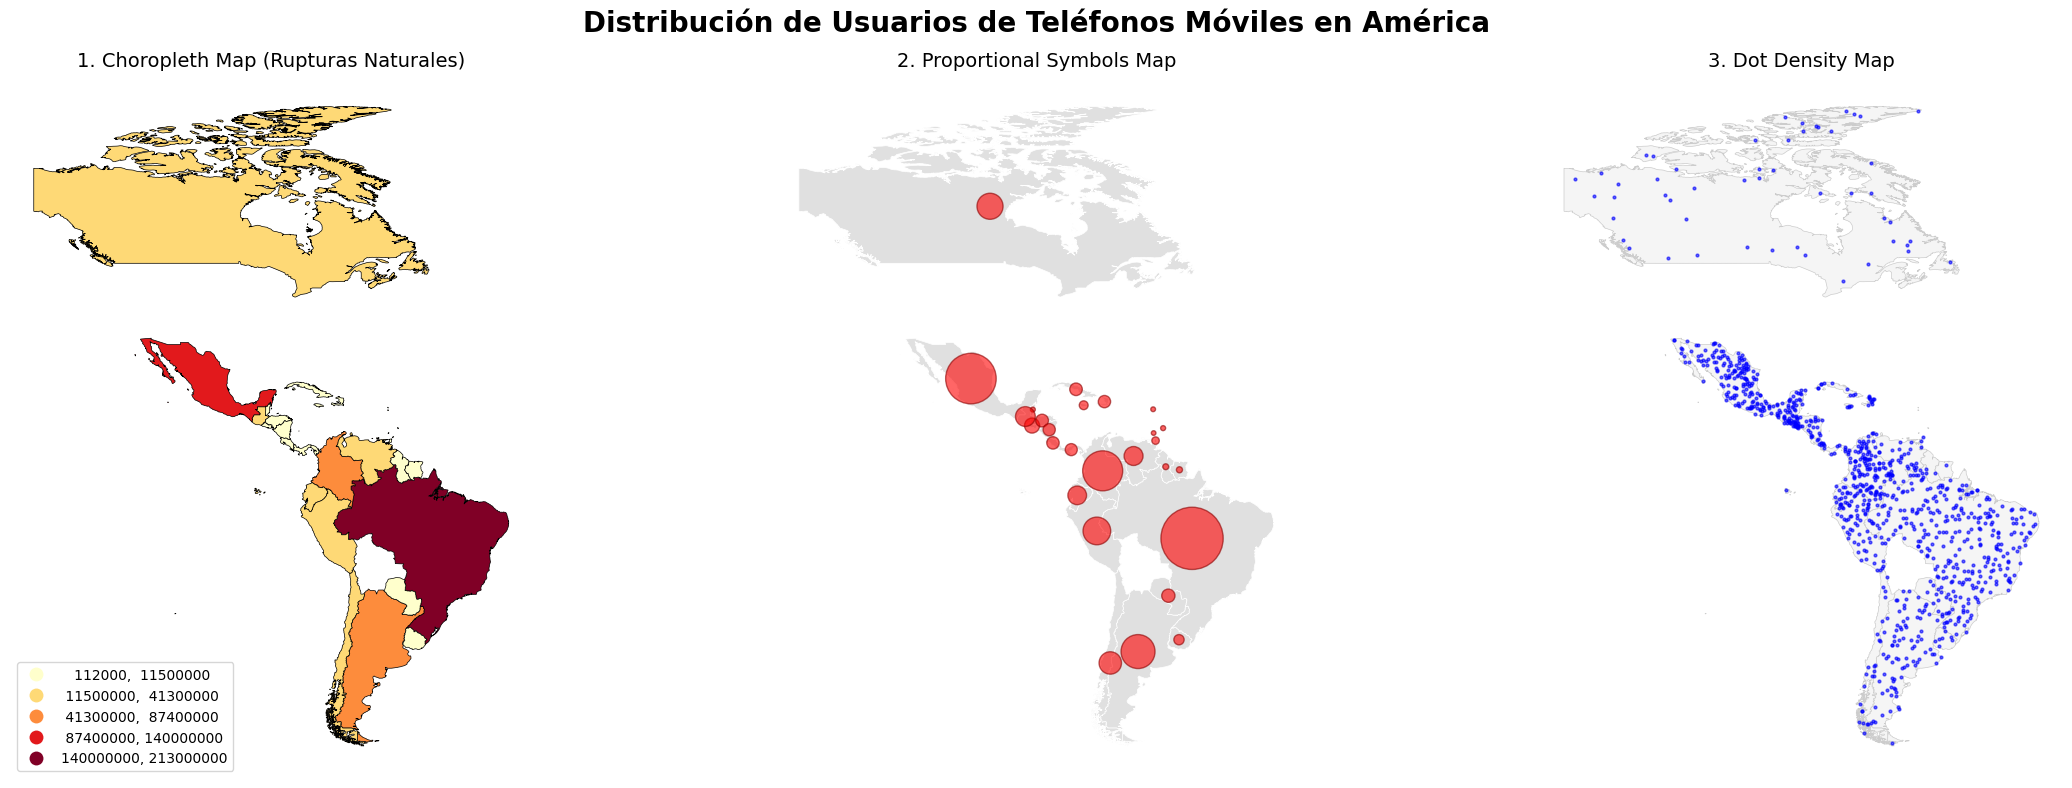

In [13]:
# 1. INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
!pip install -q mapclassify
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore') # Ocultar advertencias de CRS para mantener la salida limpia

# 2. CARGA DE DATOS (DataFrame y GeoDataFrame)
# ==============================================================================
url_csv = "https://raw.githubusercontent.com/TareasICDE/Tarea_Mapas/refs/heads/main/some_dataworld.csv"
url_mapas = "https://raw.githubusercontent.com/TareasICDE/Tarea_Mapas/refs/heads/main/worldMaps.gpkg"

df = pd.read_csv(url_csv)
mapas_paises = gpd.read_file(url_mapas, layer='countries')

# 3. LIMPIEZA Y UNIÓN (MERGE)
# ==============================================================================
# Estandarizamos texto a mayúsculas para evitar pérdidas de datos en la unión
mapas_paises['join_name'] = mapas_paises['COUNTRY'].astype(str).str.strip().str.upper()
df['join_name'] = df['Country'].astype(str).str.strip().str.upper()

mapa_unido = mapas_paises.merge(df, on='join_name')

# 4. FILTRADO ESPACIAL (Excluir lo que no sea América)
# ==============================================================================
regiones_america = ['NORTH AMERICA', 'SOUTH AMERICA', 'CENTRAL AMERICA AND THE CARIBBEAN']
america_gdf = mapa_unido[mapa_unido['region'].isin(regiones_america)].copy()

# 5. GENERACIÓN DE LOS 3 MAPAS TEMÁTICOS (Variable: 'mobiles')
# ==============================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Distribución de Usuarios de Teléfonos Móviles en América', fontsize=20, fontweight='bold')

# --- MAPA 1: CHOROPLETH MAP (Coropletas) ---
america_gdf.plot(
    column='mobiles',
    scheme='NaturalBreaks',
    k=5,
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'loc': 'lower left', 'fmt': '{:.0f}'},
    ax=ax1,
    edgecolor='black',
    linewidth=0.5
)
ax1.set_title('1. Choropleth Map (Rupturas Naturales)', fontsize=14)
ax1.set_axis_off()

# --- MAPA 2: PROPORTIONAL SYMBOLS MAP (Símbolos Proporcionales) ---
# Mapa base
america_gdf.plot(ax=ax2, color='#e0e0e0', edgecolor='white', linewidth=0.5)

# Cálculo de centroides y tamaño de burbujas (normalizado)
centroides = america_gdf.geometry.centroid
tamaño_burbuja = (america_gdf['mobiles'] / america_gdf['mobiles'].max()) * 2000 + 10

ax2.scatter(centroides.x, centroides.y, s=tamaño_burbuja, color='red', alpha=0.6, edgecolors='darkred')
ax2.set_title('2. Proportional Symbols Map', fontsize=14)
ax2.set_axis_off()

# --- MAPA 3: DOT DENSITY MAP (Densidad de Puntos) ---
# Mapa base
america_gdf.plot(ax=ax3, color='#f5f5f5', edgecolor='#cccccc', linewidth=0.5)

# Generación controlada de puntos aleatorios dentro de polígonos
np.random.seed(123)
for idx, row in america_gdf.iterrows():
    # 1 punto equivale a un porcentaje del valor máximo para no saturar el gráfico
    num_puntos = int((row['mobiles'] / america_gdf['mobiles'].max()) * 300)
    minx, miny, maxx, maxy = row.geometry.bounds
    puntos_x, puntos_y = [], []

    intentos = 0
    while len(puntos_x) < num_puntos and intentos < num_puntos * 10:
        rx, ry = np.random.uniform(minx, maxx), np.random.uniform(miny, maxy)
        if row.geometry.contains(gpd.points_from_xy([rx], [ry])[0]):
            puntos_x.append(rx)
            puntos_y.append(ry)
        intentos += 1

    ax3.scatter(puntos_x, puntos_y, s=4, color='blue', alpha=0.6)

ax3.set_title('3. Dot Density Map', fontsize=14)
ax3.set_axis_off()

# Mostrar gráfico final
plt.tight_layout()
plt.show()